# 06 RQ3：哪些技能在贬值、哪些在升值？

研究问题 3：哪些传统技能在「贬值」、哪些新兴技能在「升值」？

操作化定义（`docs/research_design.md` 第 2 节）：技能 s 的价值变化 = 渗透率变化 + 薪资溢价交叉验证。

两条证据线：
1. **需求变化**：同口径 2018 → 2023 的单技能渗透率与相对份额变化（阈值：至少一个时期命中 ≥5 次）；
2. **薪资溢价**：2025 年数据集中，提及该技能的岗位 vs 未提及岗位的月薪中位数差（阈值：命中 ≥200 次）。

双线同向 → 判定「升值」或「贬值」；背离 → 「待观察」。

In [1]:
# -*- coding: utf-8 -*-
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
ROOT = Path("..")
FIG = ROOT / "figures"

df = pd.read_csv(ROOT / "data/processed/skill_matrix_all.csv", low_memory=False)
技能列 = [c for c in df.columns if c.startswith("S_")]

## 1. 需求变化：2018 → 2023 单技能渗透率与相对份额（全文口径）

In [2]:
同口径 = df[df["数据年份"].isin([2018, 2023])]
渗透 = 同口径.groupby("数据年份")[技能列].mean().mul(100).T
渗透.columns = ["渗透2018", "渗透2023"]

# 相对份额：该技能命中次数 / 全部技能命中次数
份额 = 同口径.groupby("数据年份")[技能列].sum()
份额 = (份额.div(份额.sum(axis=1), axis=0) * 100).T
份额.columns = ["份额2018", "份额2023"]

命中数 = 同口径.groupby("数据年份")[技能列].sum().T
命中数.columns = ["命中2018", "命中2023"]

需求 = 渗透.join(份额).join(命中数)
需求["渗透变化pp"] = (需求["渗透2023"] - 需求["渗透2018"]).round(2)
需求["份额变化pp"] = (需求["份额2023"] - 需求["份额2018"]).round(2)
# 阈值：至少一个时期命中 ≥5 次，避免小样本噪声
需求 = 需求[(需求["命中2018"] >= 5) | (需求["命中2023"] >= 5)]
需求.index = [c[2:] for c in 需求.index]

print("== 份额升幅 Top10 ==")
display(需求.sort_values("份额变化pp", ascending=False).head(10).round(2))
print("== 份额降幅 Top10 ==")
display(需求.sort_values("份额变化pp").head(10).round(2))

== 份额升幅 Top10 ==


,渗透2018,渗透2023,份额2018,份额2023,命中2018,命中2023,渗透变化pp,份额变化pp
可视化,5.80,14.65,0.76,2.05,25,64,8.84,1.29
逻辑思维,40.14,46.22,5.23,6.47,173,202,6.09,1.24
统计建模,48.72,53.32,6.35,7.46,210,233,4.59,1.11
沟通能力,60.56,64.30,7.89,9.00,261,281,3.75,1.11
Python,41.30,46.22,5.38,6.47,178,202,4.92,1.09
责任心,17.40,23.80,2.27,3.33,75,104,6.40,1.06
报表制作,19.03,24.49,2.48,3.43,82,107,5.46,0.95
Tableau,1.39,7.78,0.18,1.09,6,34,6.39,0.91
数据挖掘,26.22,30.66,3.42,4.29,113,134,4.45,0.87
R语言,25.75,29.98,3.36,4.19,111,131,4.22,0.84


== 份额降幅 Top10 ==


,渗透2018,渗透2023,份额2018,份额2023,命中2018,命中2023,渗透变化pp,份额变化pp
Hive,31.32,18.54,4.08,2.59,135,81,-12.79,-1.49
Java,24.13,12.13,3.14,1.70,104,53,-12.00,-1.45
数据仓库,25.52,14.42,3.33,2.02,110,63,-11.11,-1.31
Hadoop,29.47,18.31,3.84,2.56,127,80,-11.16,-1.28
大数据,40.14,28.38,5.23,3.97,173,124,-11.76,-1.26
数据库,35.27,24.03,4.60,3.36,152,105,-11.24,-1.23
Shell,13.46,5.95,1.75,0.83,58,26,-7.51,-0.92
ETL,15.55,9.15,2.03,1.28,67,40,-6.39,-0.75
Spark,24.59,17.62,3.21,2.47,106,77,-6.97,-0.74
团队协作,37.12,29.98,4.84,4.19,160,131,-7.15,-0.64


## 2. 薪资溢价：2025 年各技能的薪资中位数差

In [3]:
d25 = df[df["数据年份"] == 2025].dropna(subset=["薪资中位k"])
d25 = d25[d25["薪资中位k"] > 0]

行 = []
for s in 技能列:
    命中 = d25[d25[s] == 1]
    if len(命中) < 200:  # 阈值：命中 ≥200 次
        continue
    未命中 = d25[d25[s] == 0]
    溢价中位 = 命中["薪资中位k"].median() - 未命中["薪资中位k"].median()
    溢价率 = (命中["薪资中位k"].median() / 未命中["薪资中位k"].median() - 1) * 100
    行.append({"技能": s[2:], "命中数": len(命中), "渗透率%": round(len(命中) / len(d25) * 100, 2),
               "提及岗位中位k": round(命中["薪资中位k"].median(), 1),
               "溢价率%": round(溢价率, 1)})
溢价表 = pd.DataFrame(行).sort_values("溢价率%", ascending=False).set_index("技能")
display(溢价表)
print("注：简单中位数差，未控制城市/学历/层级，解释为描述性关联。")

,命中数,渗透率%,提及岗位中位k,溢价率%
技能,,,,
深度学习,1844,1.79,22.5,80.0
TensorFlow,811,0.79,22.5,80.0
自然语言处理,395,0.38,22.5,80.0
计算机视觉,678,0.66,22.0,76.0
大模型与生成式AI,1165,1.13,21.5,72.0
机器学习,1727,1.68,20.5,64.0
OpenCV,787,0.76,20.0,60.0
C++,6481,6.30,20.0,60.0
Spark,352,0.34,17.5,40.0


注：简单中位数差，未控制城市/学历/层级，解释为描述性关联。


## 3. 双证据汇总：升值 / 贬值判定

,渗透2018,渗透2023,份额2018,份额2023,命中2018,命中2023,渗透变化pp,份额变化pp,渗透率%,溢价率%,命中数,判定
JavaScript,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.56,0.0,1605.0,仅2025证据: 平
计算机视觉,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.66,76.0,678.0,仅2025证据: 高溢价
大模型与生成式AI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.13,72.0,1165.0,仅2025证据: 高溢价
OpenCV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.76,60.0,787.0,仅2025证据: 高溢价
SAS,16.71,16.25,2.18,2.27,72.0,71.0,-0.46,0.10,NaN,NaN,NaN,仅跨期证据: 升
XGBoost,0.00,1.14,0.00,0.16,0.0,5.0,1.14,0.16,NaN,NaN,NaN,仅跨期证据: 升
责任心,17.40,23.80,2.27,3.33,75.0,104.0,6.40,1.06,NaN,NaN,NaN,仅跨期证据: 升
推荐系统,1.39,2.29,0.18,0.32,6.0,10.0,0.90,0.14,NaN,NaN,NaN,仅跨期证据: 升
R语言,25.75,29.98,3.36,4.19,111.0,131.0,4.22,0.84,NaN,NaN,NaN,仅跨期证据: 升
学习能力,17.63,18.54,2.30,2.59,76.0,81.0,0.90,0.30,NaN,NaN,NaN,仅跨期证据: 升


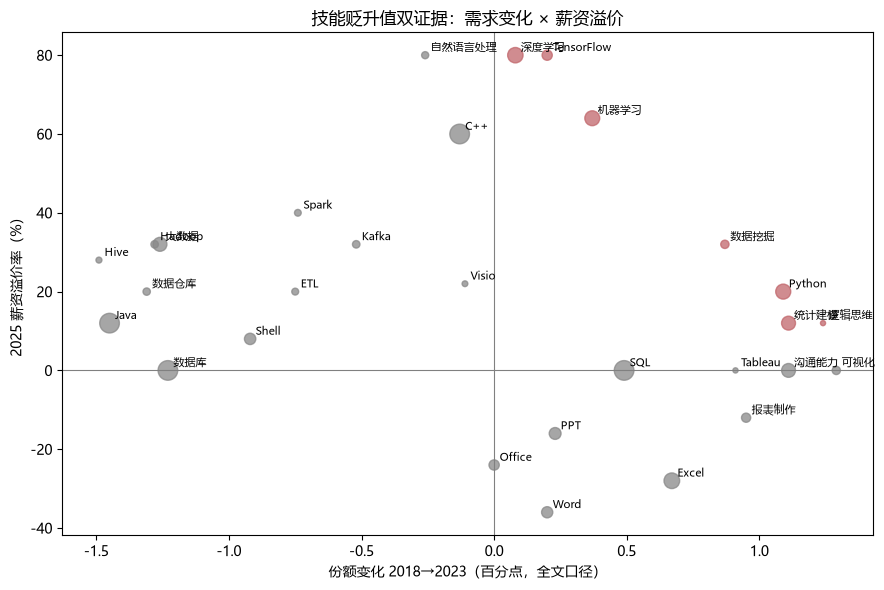

In [4]:
# 合并两条证据线（仅同时出现在两条线中的技能可判定）
汇总 = 需求.join(溢价表[["渗透率%", "溢价率%", "命中数"]], how="outer")

def 判定(行):
    升 = 行.get("份额变化pp")
    溢 = 行.get("溢价率%")
    if pd.isna(升) and pd.isna(溢):
        return "证据不足"
    if pd.isna(升):
        return "仅2025证据: " + ("高溢价" if 溢 >= 10 else ("负溢价" if 溢 < 0 else "平"))
    if pd.isna(溢):
        return "仅跨期证据: " + ("升" if 升 > 0 else "降")
    if 升 > 0 and 溢 >= 10:
        return "升值"
    if 升 < 0 and 溢 < 0:
        return "贬值"
    return "背离/待观察"

汇总["判定"] = 汇总.apply(判定, axis=1)
display(汇总.sort_values("判定").round(2))

# 散点图：跨期份额变化 x 2025 溢价率
图 = 汇总.dropna(subset=["份额变化pp", "溢价率%"])
fig, ax = plt.subplots(figsize=(9, 6))
颜色 = 图["判定"].map({"升值": "#C1666B", "贬值": "#4C9F70"}).fillna("#888888")
ax.scatter(图["份额变化pp"], 图["溢价率%"], s=图["命中数"].clip(200, 3000) / 15,
           c=颜色, alpha=0.75)
for 名, r in 图.iterrows():
    ax.annotate(名, (r["份额变化pp"], r["溢价率%"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("份额变化 2018→2023（百分点，全文口径）")
ax.set_ylabel("2025 薪资溢价率（%）")
ax.set_title("技能贬升值双证据：需求变化 × 薪资溢价")
plt.tight_layout()
plt.savefig(FIG / "15_技能贬升值_双证据.png", dpi=150)
plt.show()

## 4. 小结（RQ3）

1. **需求侧（2018→2023 同口径）**：份额升幅与降幅榜单见第 1 节；
2. **薪资侧（2025）**：AI 核心与数据工程技能普遍有正溢价，传统办公软件类溢价低或为负；
3. **双证据交叉**：需求升 + 高溢价 → 「升值」；需求降 + 负溢价 → 「贬值」；两线背离的技能标为「待观察」，在第 3 节散点图中一目了然；
4. 局限：跨期证据样本小（431/437）、城市单一（杭州 vs 南昌）；薪资溢价未控制全部混杂；2025 标签口径下低渗透技能进不了溢价榜——这些是第四阶段报告需明确披露的边界。